In [1]:
from statistic import calcular_medidas_descritivas, calcular_outliers
from distribuicao import analisar_assimetria_curtose
from graficos import gerar_histograma, gerar_painel_boxplot
import pandas as pd
import mysql.connector

In [2]:
# FUNÇÃO DE CONEXÃO COM O MYSQL

def obter_dados_do_banco(query):
    try:
        conexao = mysql.connector.connect(
            host="localhost",
            user="root",
            password="123456",
            database="projeto_vacinas"
        )

        cursor = conexao.cursor()
        cursor.execute(query)

        resultados = cursor.fetchall()

        return resultados

    except mysql.connector.Error as erro:
        print(f"Erro ao conectar ao MySQL: {erro}")
        return None

    finally:
        if 'conexao' in locals() and conexao.is_connected():
            cursor.close()
            conexao.close()

In [3]:
# CONSULTA DOS DADOS

query_idades = """
SELECT paciente_idade
FROM vacinacao_ac
WHERE paciente_idade IS NOT NULL
"""

dados = obter_dados_do_banco(query_idades)

df = pd.DataFrame(
    dados,
    columns=['paciente_idade']
)

# Convertendo para float
df['paciente_idade'] = df['paciente_idade'].astype(float)

df.head()

,paciente_idade
0,30.0
1,45.0
2,14.0
3,71.0
4,32.0


In [4]:
# PREPARAÇÃO DOS DADOS

idades_array = df['paciente_idade'].values

print(idades_array)

[30. 45. 14. ... 53. 17. 37.]


In [5]:
# MEDIDAS DESCRITIVAS

medidas = calcular_medidas_descritivas(idades_array)


===== MEDIDAS DESCRITIVAS =====
Média: 35.73
Mediana: 34.00
Moda: 18.00
Desvio Padrão: 19.74
Q1: 20.00
Q2 (Mediana): 34.00
Q3: 49.00
IQR: 29.00
Distância entre Média e Mediana: 5.07%
A média tende a ser uma medida confiável.


In [6]:
# OUTLIERS

outliers = calcular_outliers(idades_array)


===== OUTLIERS =====
Q1: 20.00
Q3: 49.00
IQR: 29.00
Limite Inferior: -23.50
Limite Superior: 92.50

Quantidade de outliers inferiores: 0
Quantidade de outliers superiores: 592


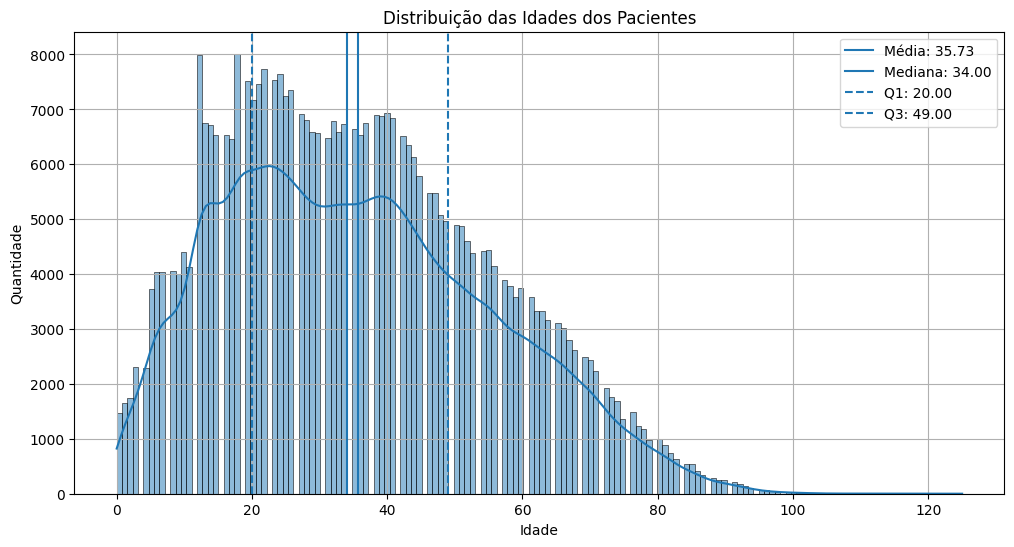

In [7]:
# HISTOGRAMA

gerar_histograma(idades_array)

Painel salvo em: Relatorio_Idades_AC.png


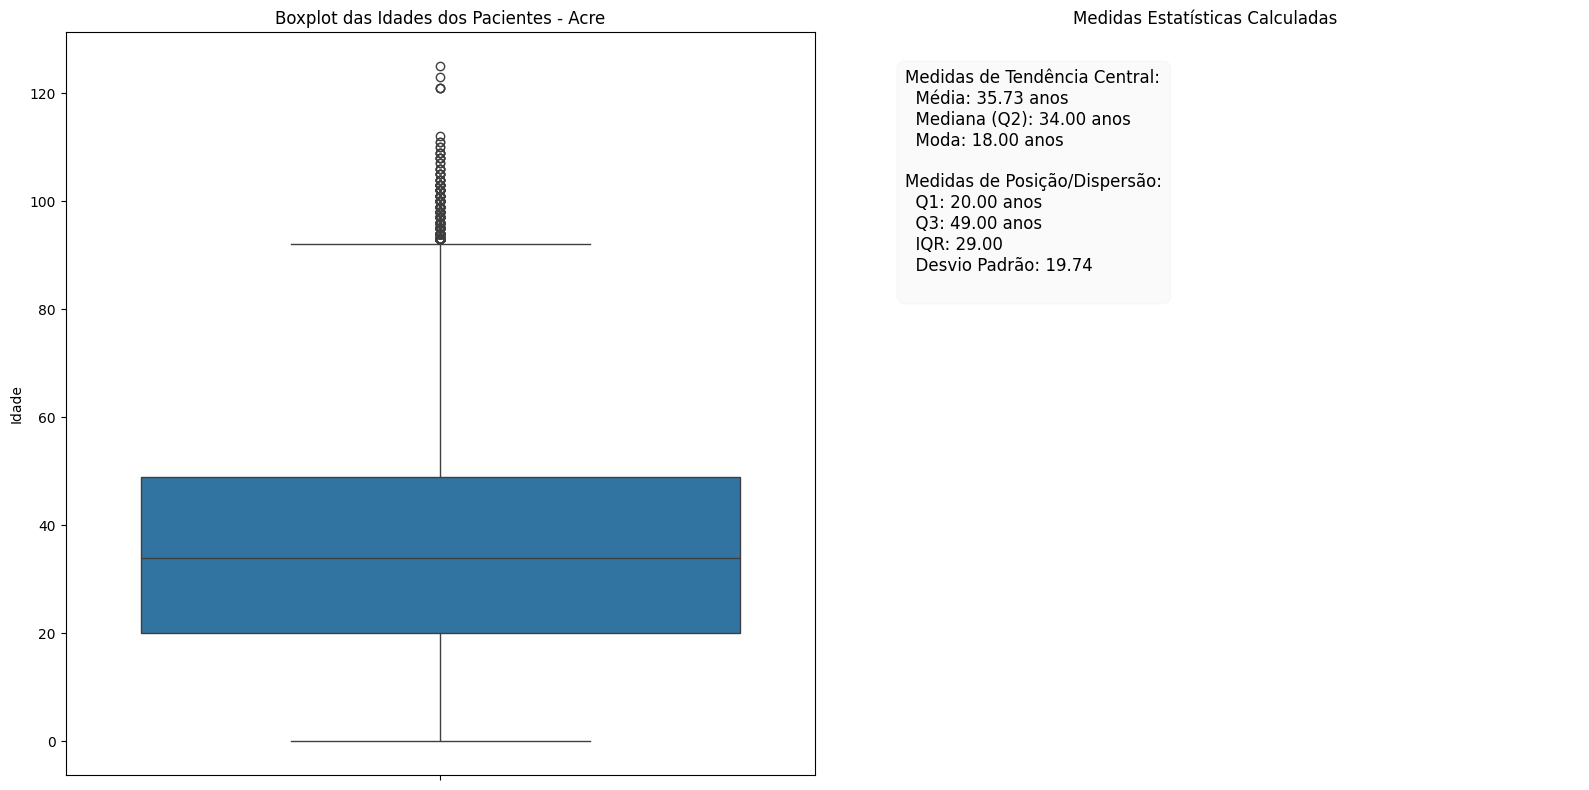

In [8]:
# BOXPLOT


gerar_painel_boxplot(
    idades_array,
    medidas,
    titulo_boxplot='Boxplot das Idades dos Pacientes - Acre',
    caminho_salvar='Relatorio_Idades_AC.png'
)

In [9]:
# ASSIMETRIA E CURTOSE

analise_distribuicao = analisar_assimetria_curtose(idades_array)


===== ASSIMETRIA =====
Assimetria das Idades: 0.4201
Média: 35.73
Mediana: 34.00

Conclusão da Assimetria: Simétrica ou quase simétrica. Média e mediana são próximas.

===== CURTOSE =====
Curtose em Excesso (Pandas): -0.5098
Curtose Real (Referência 3.0): 2.4902

Conclusão da Curtose: Platicúrtica. Dados mais dispersos em relação à média, com curva mais achatada.
